In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
from sklearn.datasets import fetch_openml


boston = fetch_openml(
    name="boston",
    version=1,
    as_frame=True
)

X = boston.data
y = boston.target.astype(float)
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [3]:
X = X.apply(pd.to_numeric)
y = pd.to_numeric(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42  #data divide in same way every time we run the code
)

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


print("Linear Regression")
print("MSE:", mean_squared_error(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))

Linear Regression
MSE: 24.291119474973538
MAE: 3.1890919658878416


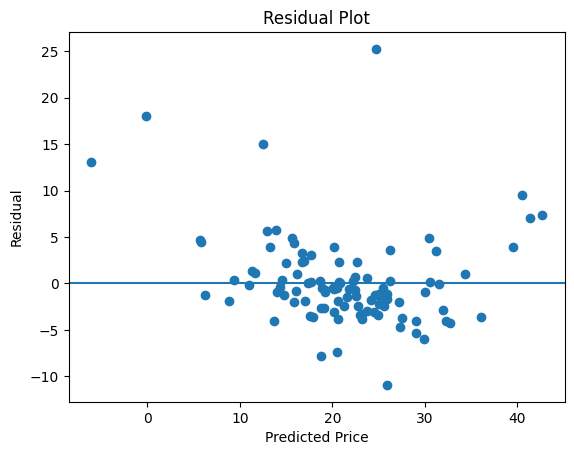

In [6]:


import matplotlib.pyplot as plt

residuals = y_test - lr_pred #find actual - predicted price difference

plt.scatter(lr_pred, residuals)

plt.axhline(0) #draw a straight line at 0 error

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [7]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)


print("Ridge Regression")
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))

Ridge Regression
MSE: 24.47719122770865
MAE: 3.1329474278055325


In [8]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)


print("Lasso Regression")
print("MSE:", mean_squared_error(y_test, lasso_pred))
print("MAE:", mean_absolute_error(y_test, lasso_pred))

Lasso Regression
MSE: 25.155593753934173
MAE: 3.1452398674037196


In [9]:
comparison = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

comparison

,Feature,Linear,Ridge,Lasso
0,CRIM,-0.113056,-0.109234,-0.104157
1,ZN,0.030110,0.032271,0.034893
2,INDUS,0.040381,0.007498,-0.016785
3,CHAS,2.784438,2.545470,0.919952
4,NOX,-17.202633,-9.537952,-0.000000
5,RM,4.438835,4.464505,4.311687
6,AGE,-0.006296,-0.012191,-0.015126
7,DIS,-1.447865,-1.338700,-1.151487
8,RAD,0.262430,0.248882,0.239237
9,TAX,-0.010647,-0.011475,-0.012962
